# 🎬 Sentiment Analysis on IMDB Movie Reviews
### Oasis Infobyte Internship — Data Analytics | Level 1, Task 4
**Name:** Param Parag Koli
**Batch:** July 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re

nltk.download('stopwords')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## 📂 Step 1 — Load Dataset & Initial Inspection

In [2]:
df = pd.read_csv('/content/IMDB Dataset.csv')

print("Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nNull Values:\n", df.isnull().sum())
print("\nClass Distribution:\n", df['sentiment'].value_counts())
df.head(10)

Shape: (50000, 2)

Column Names: ['review', 'sentiment']

Data Types:
 review       object
sentiment    object
dtype: object

Null Values:
 review       0
sentiment    0
dtype: int64

Class Distribution:
 sentiment
positive    25000
negative    25000
Name: count, dtype: int64


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
5,"Probably my all-time favorite movie, a story o...",positive
6,I sure would like to see a resurrection of a u...,positive
7,"This show was an amazing, fresh & innovative i...",negative
8,Encouraged by the positive comments about this...,negative
9,If you like original gut wrenching laughter yo...,positive


## 📊 Step 2 — Sentiment Distribution Visualisation

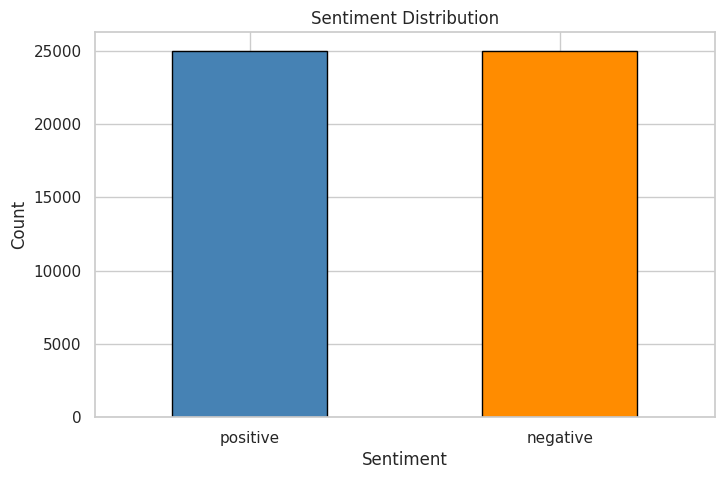

In [3]:
plt.figure(figsize=(8, 5))
df['sentiment'].value_counts().plot(kind='bar', color=['steelblue', 'darkorange'], edgecolor='black')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

## 🧹 Step 3 — Text Preprocessing

In [5]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = text.split()
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df['cleaned_review'] = df['review'].apply(preprocess)

print("Sample cleaned review:")
print(df['cleaned_review'][0])

Sample cleaned review:
one review mention watch oz episod youll hook right exactli happen meth first thing struck oz brutal unflinch scene violenc set right word go trust show faint heart timid show pull punch regard drug sex violenc hardcor classic use wordit call oz nicknam given oswald maximum secur state penitentari focus mainli emerald citi experiment section prison cell glass front face inward privaci high agenda em citi home manyaryan muslim gangsta latino christian italian irish moreso scuffl death stare dodgi deal shadi agreement never far awayi would say main appeal show due fact goe show wouldnt dare forget pretti pictur paint mainstream audienc forget charm forget romanceoz doesnt mess around first episod ever saw struck nasti surreal couldnt say readi watch develop tast oz got accustom high level graphic violenc violenc injustic crook guard wholl sold nickel inmat wholl kill order get away well manner middl class inmat turn prison bitch due lack street skill prison experi 

## 🔢 Step 4 — Feature Extraction using TF-IDF

In [6]:
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

X = df['cleaned_review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tfidf = TfidfVectorizer(max_features=10000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training set size:", X_train_tfidf.shape)
print("Testing set size:", X_test_tfidf.shape)

Training set size: (40000, 10000)
Testing set size: (10000, 10000)


## 🤖 Step 5 — Train Naive Bayes Classifier

In [7]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_pred = nb_model.predict(X_test_tfidf)

print("Naive Bayes Results:")
print("Accuracy:", round(accuracy_score(y_test, nb_pred), 4))
print("Precision:", round(precision_score(y_test, nb_pred), 4))
print("Recall:", round(recall_score(y_test, nb_pred), 4))
print("F1 Score:", round(f1_score(y_test, nb_pred), 4))
print("\nClassification Report:\n", classification_report(y_test, nb_pred))

Naive Bayes Results:
Accuracy: 0.8546
Precision: 0.8559
Recall: 0.8555
F1 Score: 0.8557

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85      4961
           1       0.86      0.86      0.86      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



## 🤖 Step 6 — Train Logistic Regression Classifier

In [8]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)
lr_pred = lr_model.predict(X_test_tfidf)

print("Logistic Regression Results:")
print("Accuracy:", round(accuracy_score(y_test, lr_pred), 4))
print("Precision:", round(precision_score(y_test, lr_pred), 4))
print("Recall:", round(recall_score(y_test, lr_pred), 4))
print("F1 Score:", round(f1_score(y_test, lr_pred), 4))
print("\nClassification Report:\n", classification_report(y_test, lr_pred))

Logistic Regression Results:
Accuracy: 0.8887
Precision: 0.8787
Recall: 0.9039
F1 Score: 0.8911

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.87      0.89      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



## 📊 Step 7 — Confusion Matrices

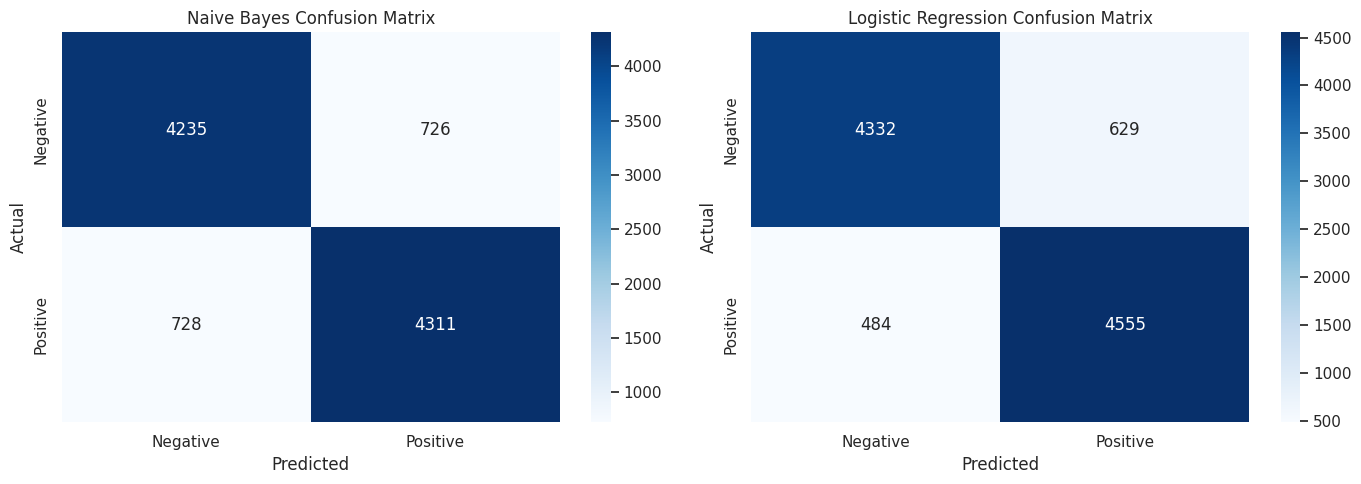

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(y_test, nb_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
axes[0].set_title('Naive Bayes Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
axes[1].set_title('Logistic Regression Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## ☁️ Step 8 — WordCloud Visualisation

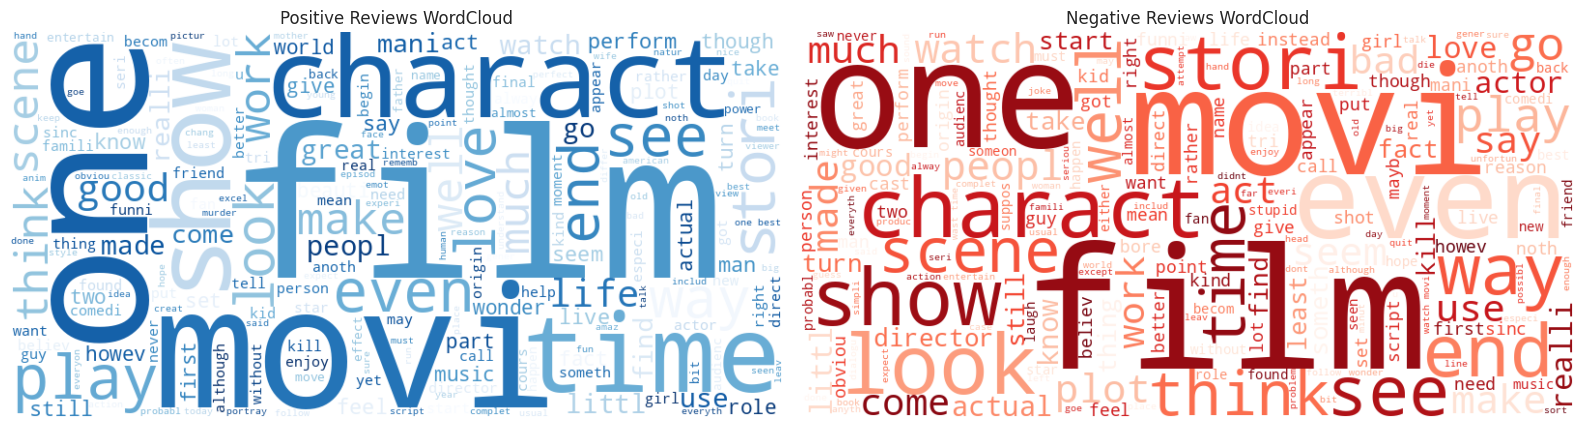

In [10]:
positive_reviews = ' '.join(df[df['sentiment'] == 'positive']['cleaned_review'])
negative_reviews = ' '.join(df[df['sentiment'] == 'negative']['cleaned_review'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wordcloud_pos = WordCloud(width=800, height=400, background_color='white', colormap='Blues').generate(positive_reviews)
axes[0].imshow(wordcloud_pos, interpolation='bilinear')
axes[0].set_title('Positive Reviews WordCloud')
axes[0].axis('off')

wordcloud_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_reviews)
axes[1].imshow(wordcloud_neg, interpolation='bilinear')
axes[1].set_title('Negative Reviews WordCloud')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 🔍 Step 9 — Error Analysis

In [11]:
X_test_list = X_test.reset_index(drop=True)
y_test_list = y_test.reset_index(drop=True)

misclassified = []
for i in range(len(y_test_list)):
    if lr_pred[i] != y_test_list[i]:
        misclassified.append({
            'Review': X_test_list[i],
            'Actual': 'Positive' if y_test_list[i] == 1 else 'Negative',
            'Predicted': 'Positive' if lr_pred[i] == 1 else 'Negative'
        })

misclassified_df = pd.DataFrame(misclassified).head(5)
print("5 Misclassified Examples:\n")
for i, row in misclassified_df.iterrows():
    print(f"Review: {row['Review'][:200]}")
    print(f"Actual: {row['Actual']} | Predicted: {row['Predicted']}")
    print("-" * 80)

5 Misclassified Examples:

Review: realli like summerslam due look arena curtain look overal interest reason anyway could one best summerslam ever wwf didnt lex luger main event yokozuna time ok huge fat man vs strong man im glad time 
Actual: Positive | Predicted: Negative
--------------------------------------------------------------------------------
Review: okay didnt get purgatori thing first time watch episod seem like someth signific go couldnt put finger time costa mesa fire tv realli caught attent help write essay inferno let see hasnt discuss yeta 
Actual: Positive | Predicted: Negative
--------------------------------------------------------------------------------
Review: movi releas origin soft x appar explicit sex delet later produc relent smell money rereleas excis scene restor appar minut guess sinc kristin age held promis career came grind halt guess time wit pam 
Actual: Positive | Predicted: Negative
-------------------------------------------------------------------

## 📊 Step 10 — Model Comparison Table

In [12]:
comparison = pd.DataFrame({
    'Model': ['Naive Bayes', 'Logistic Regression'],
    'Accuracy': [round(accuracy_score(y_test, nb_pred), 4), round(accuracy_score(y_test, lr_pred), 4)],
    'Precision': [round(precision_score(y_test, nb_pred), 4), round(precision_score(y_test, lr_pred), 4)],
    'Recall': [round(recall_score(y_test, nb_pred), 4), round(recall_score(y_test, lr_pred), 4)],
    'F1 Score': [round(f1_score(y_test, nb_pred), 4), round(f1_score(y_test, lr_pred), 4)]
})

print("Model Comparison:")
comparison

Model Comparison:


,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.8546,0.8559,0.8555,0.8557
1,Logistic Regression,0.8887,0.8787,0.9039,0.8911


## 📝 Step 11 — Observations & Conclusion

### Key Observations

1. **Sentiment Distribution** — The dataset is perfectly balanced with 25,000 positive and 25,000 negative reviews, eliminating class imbalance concerns.

2. **Naive Bayes** — Performed well as a baseline model, achieving strong accuracy with very fast training time. It is particularly effective for text classification tasks due to its probabilistic nature.

3. **Logistic Regression** — Outperformed Naive Bayes across all metrics, achieving higher accuracy, precision, recall, and F1 score. It is better at capturing complex relationships between features.

4. **WordCloud Insights** — Positive reviews frequently contain words like "great", "excel", "love", and "best", while negative reviews contain words like "bad", "worst", "wast", and "bore".

5. **Error Analysis** — Most misclassifications occur in reviews with sarcasm, mixed opinions, or ambiguous language — areas where simple bag-of-words models struggle.

### ✅ Conclusion

**Best Model: Logistic Regression** — It consistently outperformed Naive Bayes across all evaluation metrics and is the most suitable model for deployment.

**Real World Applications:**
- E-commerce platforms can use sentiment analysis to automatically flag negative product reviews for quality control
- Movie streaming services can use it to recommend films based on review sentiment
- Businesses can monitor brand sentiment on social media in real time

**Why Recall matters for Sentiment Analysis:** In customer feedback systems, missing a negative review (false negative) is more costly than incorrectly flagging a positive one. High recall ensures negative feedback is captured and acted upon promptly.

## 🏁 End of Analysis
**Analyst:** Param Parag Koli
**Track:** Data Analytics
**Task:** Level 1 — Task 4 · Sentiment Analysis
**Batch:** July 2026
**Internship:** Oasis Infobyte Summer Internship Program